# Capstone Project: Predicting US Traffic Accident Severity

**MDS Data Science Masters — Group 17**  
**Authors:** Osvaldo Rivera, Nitin Nellisserry  

---

## Table of Contents
1. Problem Statement | 2. Setup and Data Loading | 3. Exploratory Data Analysis | 4. Train/Test Split | 5. Model Training | 6. Model Comparison | 7. Advanced Feature Engineering | 8. Conclusions | Appendices

---

## 1. Problem Statement

This project aims to **predict traffic accident severity** using the US Accidents dataset. We frame the task as a **binary classification** problem:

- **Target:** `High_Severity` — whether an accident is high severity (Severity 3 or 4) or not (Severity 1 or 2).
- **Features:** Weather (temperature, humidity, visibility, precipitation, wind speed), road infrastructure (traffic signal, junction, crossing), time (hour, day of week, weekend), weather condition (one-hot), and state (one-hot).

**Goal:** Build and compare classification models to identify factors associated with high-severity accidents and provide a usable predictive model for potential deployment in traffic safety applications.

## 2. Setup and Data Loading

We load the raw US Accidents dataset, sample it for efficiency, and build the cleaned feature matrix. This includes imports, data loading, and the full preprocessing pipeline.

### 2.1 Imports and Configuration

Import required libraries for data manipulation, visualization, and modeling.

### 2.2 Data Loading, Cleaning, and Preprocessing

Load the raw CSV, sample 120,000 rows, select relevant columns, parse datetimes, create the binary target, handle missing values, one-hot encode categoricals, and engineer time/weather features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_fscore_support,
    accuracy_score,
    f1_score,
    make_scorer
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
import xgboost as xgb
from tensorflow import keras
from tensorflow.keras import layers

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
sns.set_style("whitegrid")
%matplotlib inline

In [2]:
RAW_PATH = "../datasets/US_Accidents_March23.csv"
SAMPLE_SIZE = 120_000
RANDOM_STATE = 42

# 1) Load raw and sample
df = pd.read_csv(RAW_PATH)
if len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)

# shows dtypes, to check what may need to encode
print(df.dtypes.sort_values())

# 2) Select columns
selected_cols = [
    "Severity", "Start_Time", "Temperature(F)", "Humidity(%)",
    "Visibility(mi)", "Weather_Condition", "Precipitation(in)",
    "Wind_Speed(mph)", "Traffic_Signal", "Junction", "Crossing", "State", 

    "Distance(mi)",
    "Stop",
    "Railway",
    "Roundabout",
    "Traffic_Calming",
    "Give_Way",
    "Bump",
    "Wind_Chill(F)", 
    "Pressure(in)",
    "Wind_Direction",

    "Sunrise_Sunset",
    "Civil_Twilight"
]

# print("Columns in dataset:")
# print("\n".join(df.columns))
df = df[selected_cols].copy()

# 3) Parse datetime and engineer time features
df["Start_Time"] = pd.to_datetime(df["Start_Time"], format="mixed", errors="coerce")
df = df.dropna(subset=["Start_Time"]).copy()
df["Hour"] = df["Start_Time"].dt.hour
df["DayOfWeek"] = df["Start_Time"].dt.dayofweek
df["Is_Weekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

# Month / Season Feature
df["Month"] = df["Start_Time"].dt.month
df["Is_Winter"] = df["Month"].isin([12, 1, 2]).astype(int)
df["Is_Summer"] = df["Month"].isin([6, 7, 8]).astype(int)

# Wrapping Decemebr/ January
df["Month_sin"] = np.sin(2*np.pi*df["Month"]/12)
df["Month_cos"] = np.cos(2*np.pi*df["Month"]/12)

# Cyclical encoding for time
df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)

df["Day_sin"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
df["Day_cos"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

# 4) Binary target
df["High_Severity"] = (df["Severity"] >= 3).astype(int)

# 5) Handle missing values
df["Temperature(F)"] = df["Temperature(F)"].fillna(df["Temperature(F)"].median())
df["Humidity(%)"] = df["Humidity(%)"].fillna(df["Humidity(%)"].median())
df["Visibility(mi)"] = df["Visibility(mi)"].fillna(df["Visibility(mi)"].median())
df["Precipitation(in)"] = df["Precipitation(in)"].fillna(0)
df["Wind_Speed(mph)"] = df["Wind_Speed(mph)"].fillna(df["Wind_Speed(mph)"].median())
df["Wind_Chill(F)"] = df["Wind_Chill(F)"].fillna(df["Wind_Chill(F)"].median())
df["Pressure(in)"]  = df["Pressure(in)"].fillna(df["Pressure(in)"].median())
df["Weather_Condition"] = df["Weather_Condition"].fillna("Unknown")

# 6) One-hot encode and drop Start_Time
df = df.drop(columns=["Start_Time"])
df = pd.get_dummies(df, columns=["Weather_Condition", "State", "Sunrise_Sunset", "Civil_Twilight", "Wind_Direction"], drop_first=True)

# 7) Engineered features for modeling
df["RushHour"] = (((df["Hour"] >= 7) & (df["Hour"] <= 9)) | ((df["Hour"] >= 16) & (df["Hour"] <= 19))).astype(int)
df["Low_Visibility"] = (df["Visibility(mi)"] < 3).astype(int)
df["Precipitation_log"] = np.log1p(df["Precipitation(in)"])

# Weather severity index
df["Weather_Severity_Index"] = (
    df["Precipitation(in)"] * 2
    + np.maximum(0, 5 - df["Visibility(mi)"]) * 2
    + df["Wind_Speed(mph)"] * 0.1
    + df["Low_Visibility"] * 2
)

print(df["Weather_Severity_Index"].describe())

# Optional: save for reuse 
df.to_csv("../datasets/cleaned_accidents.csv", index=False)

print("Shape:", df.shape)
df.head()

Station                     bool
Railway                     bool
Roundabout                  bool
Give_Way                    bool
Stop                        bool
Traffic_Calming             bool
Traffic_Signal              bool
Crossing                    bool
Junction                    bool
Bump                        bool
Turning_Loop                bool
Amenity                     bool
No_Exit                     bool
Severity                   int64
Wind_Chill(F)            float64
Pressure(in)             float64
Visibility(mi)           float64
Temperature(F)           float64
Humidity(%)              float64
Distance(mi)             float64
End_Lng                  float64
End_Lat                  float64
Start_Lng                float64
Start_Lat                float64
Wind_Speed(mph)          float64
Precipitation(in)        float64
Sunrise_Sunset            object
Civil_Twilight            object
ID                        object
Wind_Direction            object
Source    

,Severity,Temperature(F),Humidity(%),Visibility(mi),Precipitation(in),Wind_Speed(mph),Traffic_Signal,Junction,Crossing,Distance(mi),Stop,Railway,Roundabout,Traffic_Calming,Give_Way,Bump,Wind_Chill(F),Pressure(in),Hour,DayOfWeek,...,Wind_Direction_NNE,Wind_Direction_NNW,Wind_Direction_NW,Wind_Direction_North,Wind_Direction_S,Wind_Direction_SE,Wind_Direction_SSE,Wind_Direction_SSW,Wind_Direction_SW,Wind_Direction_South,Wind_Direction_VAR,Wind_Direction_Variable,Wind_Direction_W,Wind_Direction_WNW,Wind_Direction_WSW,Wind_Direction_West,RushHour,Low_Visibility,Precipitation_log,Weather_Severity_Index
7133276,1,78.0,81.0,10.0,0.01,13.0,True,False,False,0.000,False,False,False,False,False,False,78.0,30.13,9,4,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,0,0.00995,1.32
5363845,2,55.0,88.0,10.0,0.00,9.0,False,False,True,0.045,True,False,False,False,False,False,55.0,29.83,10,3,...,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,0,0,0.00000,0.90
155993,3,91.0,47.0,10.0,0.00,10.4,False,False,True,0.000,False,False,False,False,False,False,62.0,29.91,16,4,...,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,1,0,0.00000,1.04
1861414,3,67.0,84.0,10.0,0.00,3.0,False,False,False,0.000,False,False,False,False,False,False,67.0,29.78,15,4,...,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,0,0,0.00000,0.30
2021359,2,95.0,16.0,10.0,0.00,6.0,False,False,False,0.000,False,False,False,False,False,False,95.0,28.53,16,0,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,1,0,0.00000,0.60


## 3. Exploratory Data Analysis

We explore the cleaned dataset: data overview, missing values, target distribution, severity by hour, infrastructure flags, and weather condition groupings.

### 3.1 Data Overview and Missing Values

Basic info about the dataset shape, dtypes, and missing value counts.

In [3]:
# Basic overview
print(df.info())
print("\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "None")

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 7133276 to 5656635
Columns: 187 entries, Severity to Weather_Severity_Index
dtypes: bool(161), float64(16), int32(3), int64(7)
memory usage: 41.8 MB
None

Missing values:
None


In [4]:
# Weather Conditions Print out
weather_cols = [c.replace("Weather_Condition_", "") for c in df.columns if c.startswith("Weather_Condition_")]

for i, w in enumerate(sorted(weather_cols), 1):
    print(f"{i:02d}. {w}")

01. Blowing Dust / Windy
02. Blowing Snow
03. Blowing Snow / Windy
04. Clear
05. Cloudy
06. Cloudy / Windy
07. Drizzle
08. Drizzle / Windy
09. Drizzle and Fog
10. Fair
11. Fair / Windy
12. Fog
13. Fog / Windy
14. Freezing Rain
15. Hail
16. Haze
17. Haze / Windy
18. Heavy Drizzle
19. Heavy Rain
20. Heavy Rain / Windy
21. Heavy Snow
22. Heavy Snow / Windy
23. Heavy T-Storm
24. Heavy T-Storm / Windy
25. Heavy Thunderstorms and Rain
26. Ice Pellets
27. Light Drizzle
28. Light Drizzle / Windy
29. Light Freezing Drizzle
30. Light Freezing Fog
31. Light Freezing Rain
32. Light Freezing Rain / Windy
33. Light Ice Pellets
34. Light Rain
35. Light Rain / Windy
36. Light Rain Shower
37. Light Rain with Thunder
38. Light Sleet
39. Light Snow
40. Light Snow / Windy
41. Light Snow and Sleet
42. Light Snow with Thunder
43. Light Thunderstorms and Rain
44. Mist
45. Mostly Cloudy
46. Mostly Cloudy / Windy
47. N/A Precipitation
48. Overcast
49. Partial Fog
50. Partly Cloudy
51. Partly Cloudy / Windy
52.

High_Severity distribution:
High_Severity
0    0.8047
1    0.1953
Name: proportion, dtype: float64


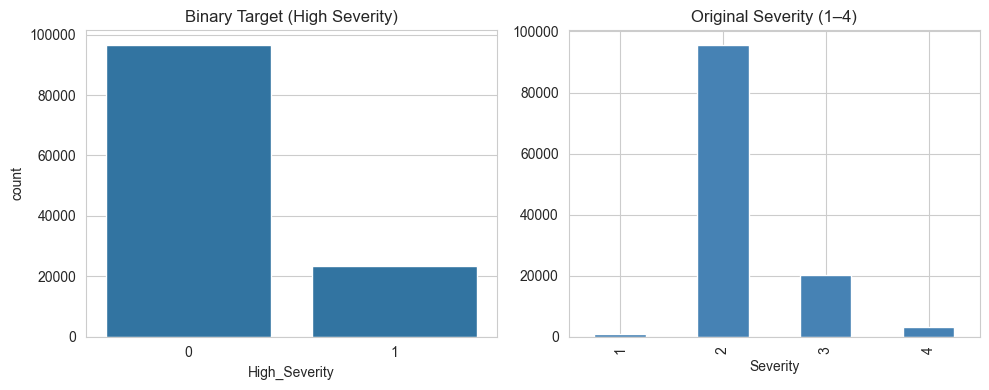

In [5]:
# Target distribution
print("High_Severity distribution:")
print(df["High_Severity"].value_counts(normalize=True))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x="High_Severity", data=df, ax=axes[0])
axes[0].set_title("Binary Target (High Severity)")
df["Severity"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Original Severity (1–4)")
axes[1].set_xlabel("Severity")
plt.tight_layout()
plt.show()

In [6]:
# Numeric feature summaries
numeric_cols = ["Temperature(F)", "Humidity(%)", "Visibility(mi)", "Precipitation(in)", "Wind_Speed(mph)", "Hour", "DayOfWeek", "Is_Weekend"]
numeric_present = [c for c in numeric_cols if c in df.columns]
if numeric_present:
    print(df[numeric_present].describe())

       Temperature(F)    Humidity(%)  Visibility(mi)  Precipitation(in)  Wind_Speed(mph)           Hour      DayOfWeek     Is_Weekend
count   120000.000000  120000.000000   120000.000000      120000.000000    120000.000000  120000.000000  120000.000000  120000.000000
mean        61.636560      64.881375        9.111385           0.005843         7.626853      12.342550       2.605600       0.161508
std         18.867676      22.535065        2.643636           0.085562         5.634831       5.479414       1.809561       0.368001
min        -89.000000       2.000000        0.000000           0.000000         0.000000       0.000000       0.000000       0.000000
25%         50.000000      49.000000       10.000000           0.000000         5.000000       8.000000       1.000000       0.000000
50%         64.000000      67.000000       10.000000           0.000000         7.000000      13.000000       3.000000       0.000000
75%         75.900000      84.000000       10.000000          

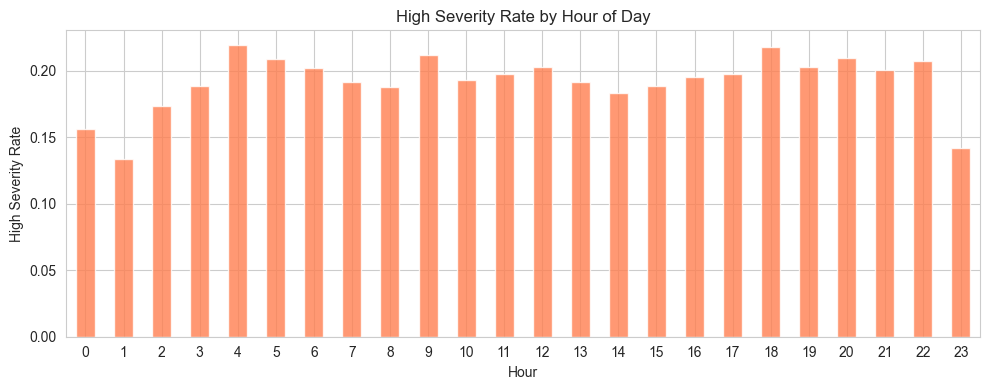

In [7]:
# High severity rate by hour
if "Hour" in df.columns:
    hr_rate = df.groupby("Hour")["High_Severity"].mean()
    plt.figure(figsize=(10, 4))
    hr_rate.plot(kind="bar", color="coral", alpha=0.8)
    plt.title("High Severity Rate by Hour of Day")
    plt.xlabel("Hour")
    plt.ylabel("High Severity Rate")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

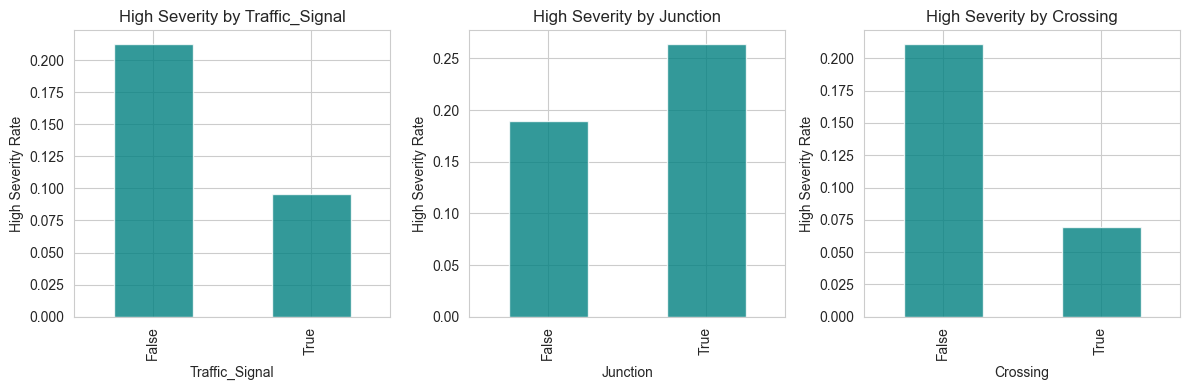

In [8]:
# Infrastructure flags vs high severity
infra = ["Traffic_Signal", "Junction", "Crossing"]
infra_present = [c for c in infra if c in df.columns]
if infra_present:
    fig, axes = plt.subplots(1, len(infra_present), figsize=(4 * len(infra_present), 4))
    if len(infra_present) == 1:
        axes = [axes]
    for ax, col in zip(axes, infra_present):
        df.groupby(col)["High_Severity"].mean().plot(kind="bar", ax=ax, color="teal", alpha=0.8)
        ax.set_title(f"High Severity by {col}")
        ax.set_ylabel("High Severity Rate")
    plt.tight_layout()
    plt.show()

### 3.4 Feature Engineering: Weather Grouping and Interactions

Collapse one-hot weather columns into interpretable groups and add interaction features (e.g., RushHour × Rain).

In [9]:
# Collapse Weather into 6 groups
# 1) Grab the full one-hot column list
wcols = [c for c in df.columns if c.startswith("Weather_Condition_")]

# 2) Helper to build groups by specifying the "suffixes" exactly as in your printout
def cols_for(suffixes):
    return [f"Weather_Condition_{s}" for s in suffixes if f"Weather_Condition_{s}" in df.columns]

CLEAR_CLOUDY = [
    "Clear","Fair","Cloudy","Mostly Cloudy","Partly Cloudy",
    "Overcast","Scattered Clouds",
    "Cloudy / Windy","Fair / Windy","Mostly Cloudy / Windy","Partly Cloudy / Windy"
]

RAIN = [
    "Drizzle","Light Drizzle","Heavy Drizzle","Drizzle / Windy","Light Drizzle / Windy","Drizzle and Fog",
    "Rain","Light Rain","Heavy Rain","Rain / Windy","Light Rain / Windy","Heavy Rain / Windy",
    "Rain Showers","Light Rain Shower","Showers in the Vicinity",
    "Freezing Rain","Light Freezing Rain","Light Freezing Rain / Windy","Light Freezing Drizzle"
]

SNOW_ICE = [
    "Snow","Light Snow","Heavy Snow","Snow / Windy","Light Snow / Windy","Heavy Snow / Windy",
    "Sleet","Light Sleet","Snow and Sleet","Snow and Sleet / Windy","Light Snow and Sleet",
    "Wintry Mix","Wintry Mix / Windy",
    "Ice Pellets","Light Ice Pellets",
    "Hail","Small Hail"
]

LOW_VIS = [
    "Fog","Mist","Partial Fog","Patches of Fog","Shallow Fog","Light Freezing Fog",
    "Fog / Windy","Shallow Fog / Windy",
    "Haze","Haze / Windy",
    "Smoke","Smoke / Windy",
    "Blowing Dust / Windy","Widespread Dust",
]

STORM = [
    "T-Storm","T-Storm / Windy",
    "Thunder","Thunder / Windy","Thunder in the Vicinity",
    "Thunderstorm","Thunderstorms and Rain","Heavy Thunderstorms and Rain",
    "Heavy T-Storm","Heavy T-Storm / Windy",
    "Light Thunderstorms and Rain","Light Rain with Thunder","Light Snow with Thunder",
]

OTHER = [
    "Tornado","Unknown","N/A Precipitation","Blowing Snow","Blowing Snow / Windy"
]

# 3) Create grouped features (max across relevant one-hot cols)
df["W_ClearCloudy"] = df[cols_for(CLEAR_CLOUDY)].max(axis=1) if cols_for(CLEAR_CLOUDY) else 0
df["W_Rain"]       = df[cols_for(RAIN)].max(axis=1)          if cols_for(RAIN) else 0
df["W_SnowIce"]    = df[cols_for(SNOW_ICE)].max(axis=1)      if cols_for(SNOW_ICE) else 0
df["W_LowVis"]     = df[cols_for(LOW_VIS)].max(axis=1)       if cols_for(LOW_VIS) else 0
df["W_Storm"]      = df[cols_for(STORM)].max(axis=1)         if cols_for(STORM) else 0

# 4) "Other" = any weather condition that isn't covered by the 5 groups above
covered = set(cols_for(CLEAR_CLOUDY)+cols_for(RAIN)+cols_for(SNOW_ICE)+cols_for(LOW_VIS)+cols_for(STORM))
remaining = [c for c in wcols if c not in covered]
df["W_Other"] = df[remaining].max(axis=1) if remaining else 0

# 5) Drop the original one-hot weather columns
df.drop(columns=wcols, inplace=True)

# 6) one compact "bad weather" flag
df["Bad_Weather"] = ((df["W_Rain"] | df["W_SnowIce"] | df["W_LowVis"] | df["W_Storm"]) > 0).astype(int)

print(df[["W_ClearCloudy","W_Rain","W_SnowIce","W_LowVis","W_Storm","W_Other"]].sum().sort_values(ascending=False))
print("Rows with no weather group flagged:",
      (df[["W_ClearCloudy","W_Rain","W_SnowIce","W_LowVis","W_Storm","W_Other"]].sum(axis=1) == 0).sum())

# Ensuring old weather cols are gone
[c for c in df.columns if "Weather_Condition" in c]

W_ClearCloudy    101980
W_Rain             8046
W_LowVis           3201
W_Other            2732
W_SnowIce          2689
W_Storm            1351
dtype: int64
Rows with no weather group flagged: 1


[]

In [10]:
# Interaction features
df["RushHour_Rain"] = df["RushHour"] * df["W_Rain"]
df["Night"] = ((df["Hour"] <= 5) | (df["Hour"] >= 21)).astype(int)
df["Night_LowVis"] = df["Night"] * df["Low_Visibility"]
df["Storm_LowVis"] = df["W_Storm"] * df["Low_Visibility"]

# Some more
df["WeekendNight"] = df["Is_Weekend"] * df["Night"]
df["RushHour_Weekday"] = df["RushHour"] * (1 - df["Is_Weekend"])

## 4. Train/Test Split and Feature Matrix

In [11]:
# Target
y = df["High_Severity"].copy()

# Features: drop ID-like and target columns
drop_cols = ["Severity", "High_Severity"]
X = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

# Keep numeric and boolean columns (cleaned data has one-hot and flags)
X = X.select_dtypes(include=[np.number, 'bool'])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print("Train size:", len(X_train), "Test size:", len(X_test))

Feature matrix shape: (120000, 119)
Target shape: (120000,)
Train size: 90000 Test size: 30000


In [12]:
# Clip numeric features to 1st–99th percentile (using train stats) to reduce outlier impact
X_train = X_train.copy()
X_test = X_test.copy()
num_cols = X_train.select_dtypes(include=[np.number]).columns
for c in num_cols:
    low, high = X_train[c].quantile(0.01), X_train[c].quantile(0.99)
    X_train[c] = X_train[c].clip(low, high)
    X_test[c] = X_test[c].clip(low, high)
print("Outlier clipping applied (train percentiles).")

Outlier clipping applied (train percentiles).


In [13]:
# Feature scaling (fit on train, transform train and test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaled feature shapes:", X_train_scaled.shape, X_test_scaled.shape)

Scaled feature shapes: (90000, 119) (30000, 119)


In [14]:
from pathlib import Path
import joblib

artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

preprocessing_artifacts = {}
for _name in [
    "X",
    "y",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "X_train_scaled",
    "X_test_scaled",
    "scaler",
]:
    if _name in globals():
        preprocessing_artifacts[_name] = globals()[_name]

joblib.dump(preprocessing_artifacts, artifacts_dir / "preprocessing_artifacts.joblib")
print("Saved preprocessing artifacts to", artifacts_dir / "preprocessing_artifacts.joblib")


Saved preprocessing artifacts to artifacts\preprocessing_artifacts.joblib
